# Kompic PPG+BCG -- Recording Analysis

**v1.0 | 2026-08-26**

The notebook loads `/sd/data/ppgbcg/s<boot>_r<seq>.csv` files written by the Stage 17 `FCM_PPG_BCG` mode. Each file contains two interleaved streams. The `src` column tags each row as `ppg` (MAX30101 raw green counts) or `bcg` (LSM6DSV16X accel-Z, already HPF+LPF filtered on the device).

For each recording the notebook runs the common pipeline in `kompic_analysis`:

1. Split the file into a PPG stream and a BCG stream.
2. Bandpass each stream to its physiological band (PPG 0.5-5 Hz, BCG 1-15 Hz).
3. Detect stable regions with a rolling MAD gate.
4. Detect beats with an adaptive-threshold peak detector.
5. Report BPM statistics, noise floor, SNR, and firmware-vs-offline beat counts.

**First bench data (2026-08-26):** two 60 s recordings. Recording A has manhandling for the first 3 s and the last 3 s. Recording B is a fully rested arm.

Change `DATA_DIR` to point at the session folder pulled from the SD card.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kompic_analysis import KompicRecording, analyze_folder, summarize
from kompic_plots    import (
    plot_overview, plot_stable_close, plot_rr_histogram,
    plot_stream_full, plot_combined_overview,
)

# Point this at the session folder pulled from the SD card. Names look like
# s0008_r0001.csv (boot_seq=8, rec_seq=1).
DATA_DIR = Path('/home/ivan/Projekti/Elektronika/Kompic-Wearable/kompic-wearable/docs/build_info/reference_files/kompic_data/ppgbcg')
assert DATA_DIR.exists(), DATA_DIR

# List every ppgbcg CSV in the folder so the analyst can copy the right
# filename into GOLDEN / MANHANDLED in the cells below.
csvs = sorted(DATA_DIR.glob('s*_r*.csv'))
for p in csvs:
    print(p.name)

s0011_r0001.csv
s0011_r0002.csv


## 1. Batch summary -- two rows per file (one per modality)

`summarize` returns a long-format table with a `modality` column so the PPG and BCG rows sit side-by-side per file. Watch for:

- `fs_hz` -- BCG should sit near 200 Hz. PPG runs at the effective MAX30101 FIFO rate, about 12 Hz with the current SR=100 Hz / SMP_AVE=8 configuration.
- `stable_frac` -- fraction of the recording that survives the movement gate. A clean rest recording sits above 0.9.
- `n_peaks_stable` vs `n_fw_beats_stable` -- close counts mean the firmware detector agrees with the offline detector.
- `snr_db` -- rest recordings should sit above about 15 dB for BCG. PPG SNR depends heavily on green LED contact.

In [2]:
results = analyze_folder(DATA_DIR)
df = summarize(results)
df

,file,fs_hz,duration_s,polarity,stable_frac,n_peaks_total,n_peaks_stable,n_fw_beats,n_fw_beats_stable,bpm_median,bpm_mean,sdnn_ms,rmssd_ms,noise_rms,peak_amp,snr_db,modality
0,s0011_r0001.csv,200.0,113.1,1,0.359,36,7,130,67,78.4,73.9,479.2,752.7,0.003,-0.009,NaN,bcg
1,s0011_r0001.csv,12.5,113.1,1,0.339,51,0,0,0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,ppg
2,s0011_r0002.csv,200.0,75.9,-1,0.930,5,0,12,7,NaN,NaN,0.0,0.0,NaN,NaN,NaN,bcg
3,s0011_r0002.csv,12.5,75.9,1,0.956,14,9,0,0,NaN,NaN,0.0,0.0,2.464,1.904,-2.2,ppg


## 2. Golden reference -- fully rested arm

The fully rested 60 s recording. The middle 54 s should show a clean signal on both streams. Use the plots to calibrate expected noise floor and beat amplitude.

pc_sync offset (us): None
PPG: {'file': 'ppg', 'fs_hz': 12.5, 'duration_s': 75.9, 'polarity': 1, 'stable_frac': 0.956, 'n_peaks_total': 14, 'n_peaks_stable': 9, 'n_fw_beats': 0, 'n_fw_beats_stable': 0, 'bpm_median': nan, 'bpm_mean': nan, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'noise_rms': 2.464, 'peak_amp': 1.904, 'snr_db': -2.2}
BCG: {'file': 'bcg', 'fs_hz': 200.0, 'duration_s': 75.9, 'polarity': -1, 'stable_frac': 0.93, 'n_peaks_total': 5, 'n_peaks_stable': 0, 'n_fw_beats': 12, 'n_fw_beats_stable': 7, 'bpm_median': nan, 'bpm_mean': nan, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'noise_rms': nan, 'peak_amp': nan, 'snr_db': nan}


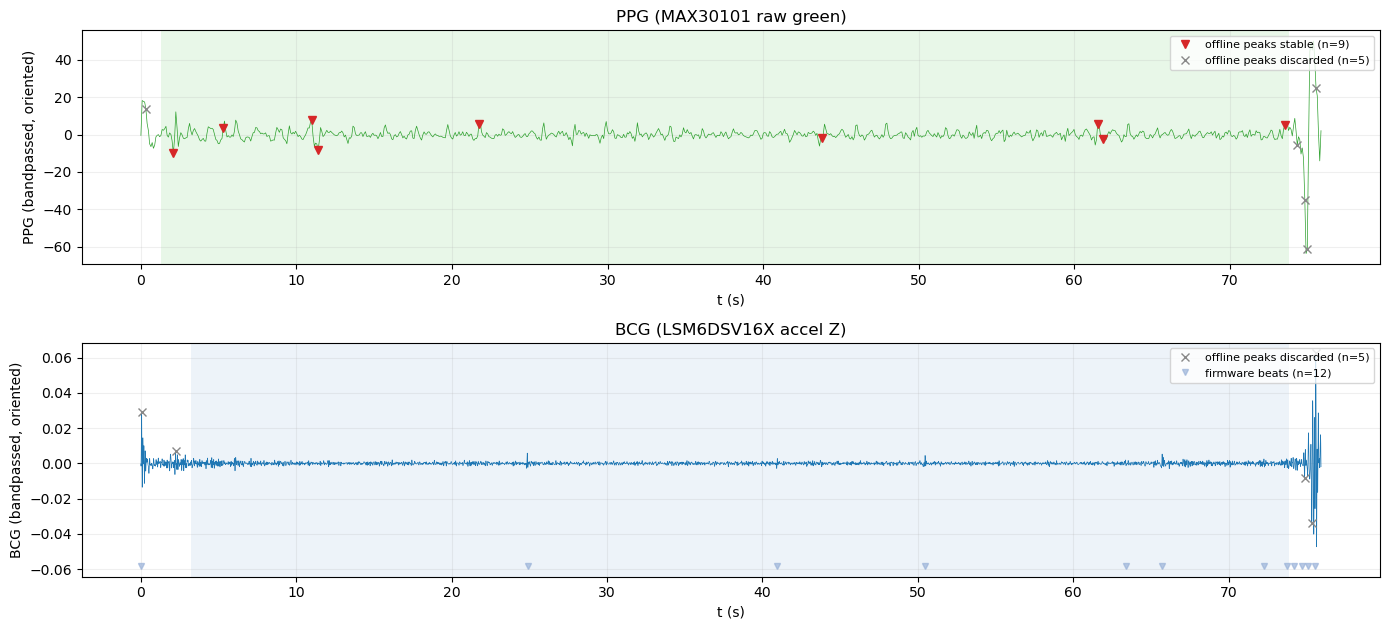

In [3]:
# Replace with the actual filename of the rested-arm recording.
GOLDEN = 's0011_r0002.csv'

rec = KompicRecording.from_csv(DATA_DIR / GOLDEN)
print('pc_sync offset (us):', rec.sync_offset_us())

ppg = rec.analyze_ppg()
bcg = rec.analyze_bcg()
if ppg is not None: print('PPG:', ppg.summary_dict())
if bcg is not None: print('BCG:', bcg.summary_dict())

plot_combined_overview(ppg, bcg);

## 3. Manhandled recording -- movement artefacts

The recording that starts and ends with 3 s of hand movement. The stable-region gate should mask both ends and keep the peak detector honest. Expect `stable_frac` close to 0.9 (54 s of 60 s).

pc_sync offset (us): None
PPG: {'file': 'ppg', 'fs_hz': 12.5, 'duration_s': 113.1, 'polarity': 1, 'stable_frac': 0.339, 'n_peaks_total': 51, 'n_peaks_stable': 0, 'n_fw_beats': 0, 'n_fw_beats_stable': 0, 'bpm_median': nan, 'bpm_mean': nan, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'noise_rms': nan, 'peak_amp': nan, 'snr_db': nan}
BCG: {'file': 'bcg', 'fs_hz': 200.0, 'duration_s': 113.1, 'polarity': 1, 'stable_frac': 0.359, 'n_peaks_total': 36, 'n_peaks_stable': 7, 'n_fw_beats': 130, 'n_fw_beats_stable': 67, 'bpm_median': 78.4, 'bpm_mean': 73.9, 'sdnn_ms': 479.2, 'rmssd_ms': 752.7, 'noise_rms': 0.003, 'peak_amp': -0.009, 'snr_db': nan}


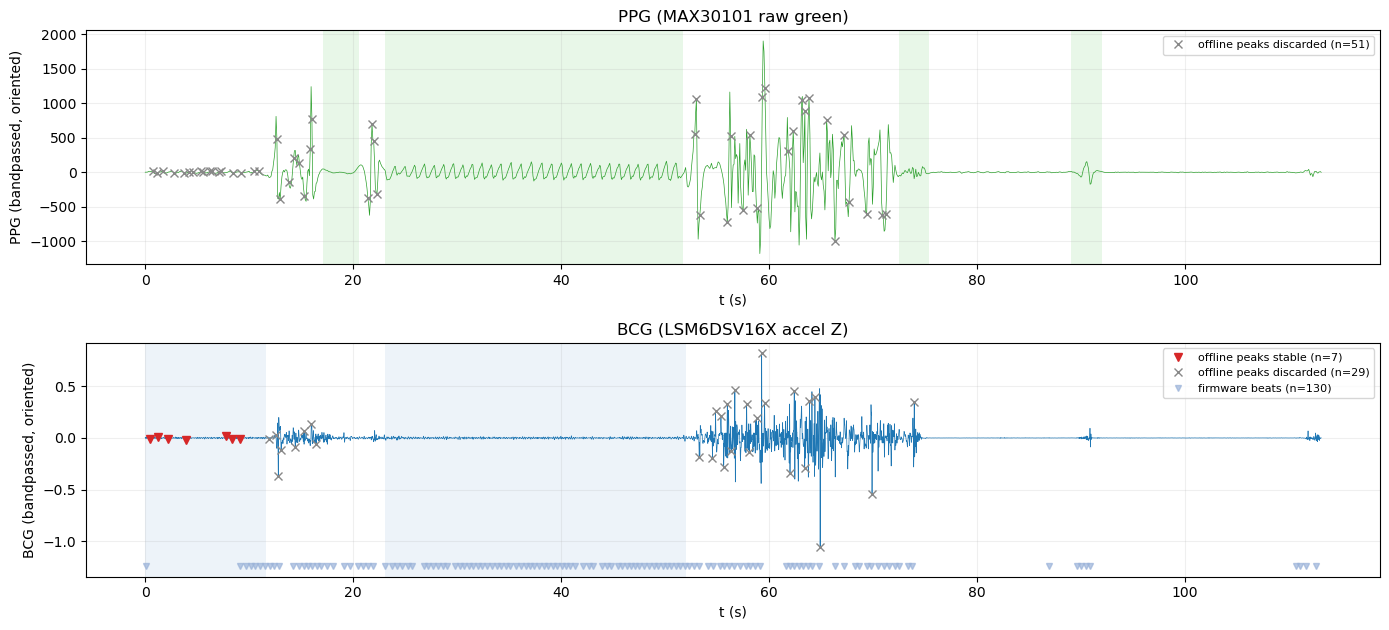

In [5]:
# Replace with the actual filename of the manhandled recording.
MANHANDLED = 's0011_r0001.csv'

rec = KompicRecording.from_csv(DATA_DIR / MANHANDLED)
print('pc_sync offset (us):', rec.sync_offset_us())

ppg = rec.analyze_ppg()
bcg = rec.analyze_bcg()
if ppg is not None: print('PPG:', ppg.summary_dict())
if bcg is not None: print('BCG:', bcg.summary_dict())

plot_combined_overview(ppg, bcg);

## 4. Full triple-panel view per stream

For a chosen recording, plot the overview, one stable-segment close-up, and the RR interval histogram. Run once per modality. The BCG plot shows the on-device HPF+LPF chain plus the offline bandpass; the PPG plot shows the offline bandpass applied to raw green counts.

PPG: {'file': 'ppg', 'fs_hz': 12.5, 'duration_s': 75.9, 'polarity': 1, 'stable_frac': 0.956, 'n_peaks_total': 14, 'n_peaks_stable': 9, 'n_fw_beats': 0, 'n_fw_beats_stable': 0, 'bpm_median': nan, 'bpm_mean': nan, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'noise_rms': 2.464, 'peak_amp': 1.904, 'snr_db': -2.2}


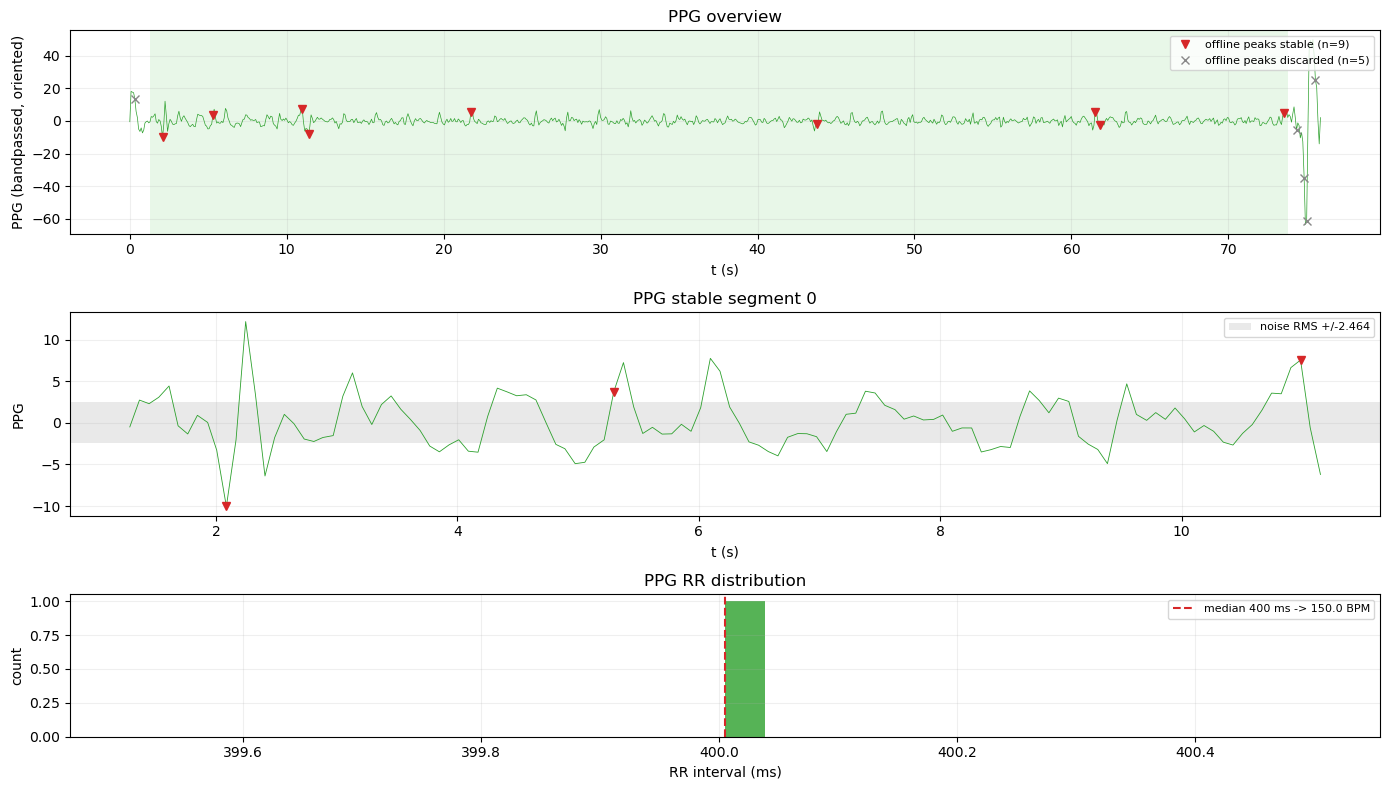

BCG: {'file': 'bcg', 'fs_hz': 200.0, 'duration_s': 75.9, 'polarity': -1, 'stable_frac': 0.93, 'n_peaks_total': 5, 'n_peaks_stable': 0, 'n_fw_beats': 12, 'n_fw_beats_stable': 7, 'bpm_median': nan, 'bpm_mean': nan, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'noise_rms': nan, 'peak_amp': nan, 'snr_db': nan}


/home/ivan/Projekti/Elektronika/Kompic-Wearable/kompic-wearable/docs/build_info/aux_scripts/sync_ecg/kompic_plots.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=8)


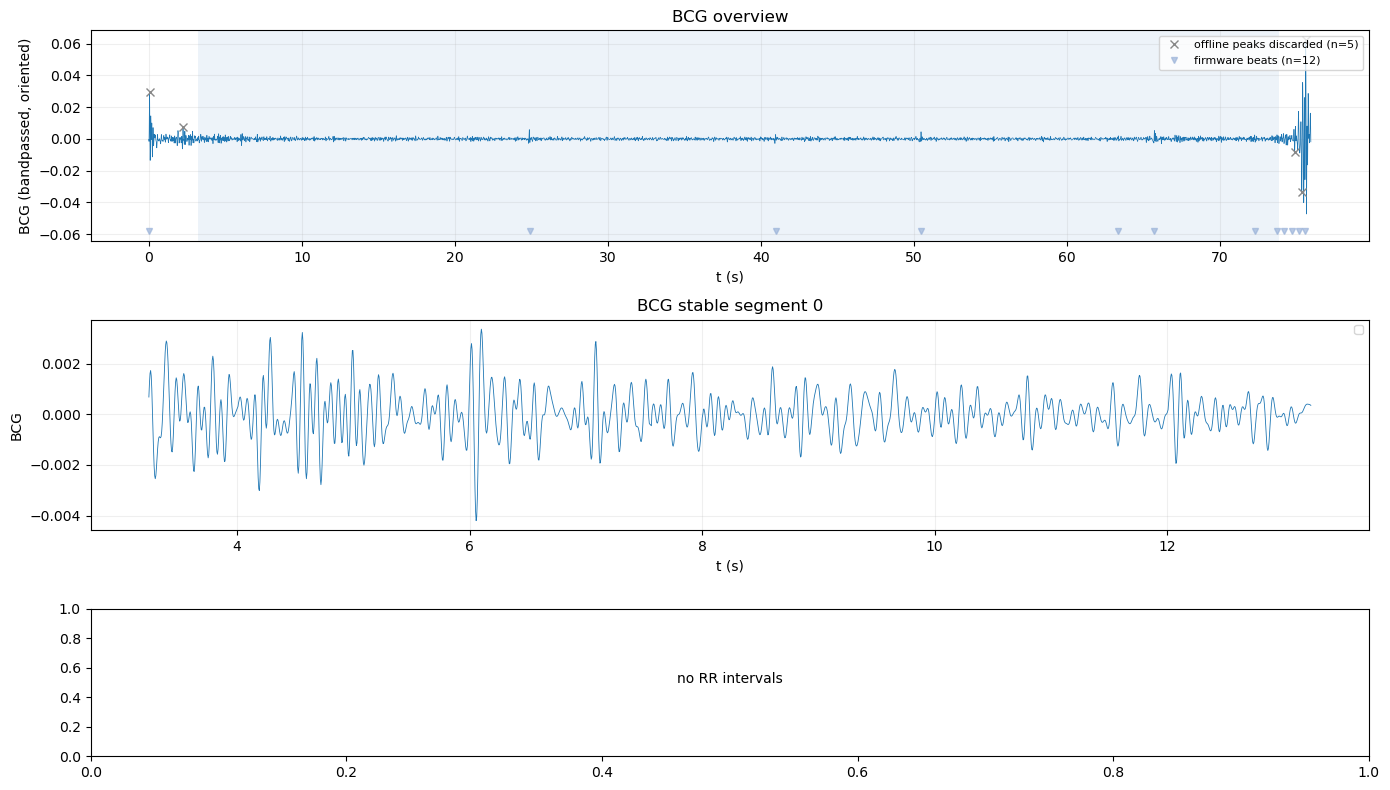

In [6]:
def inspect(name):
    rec = KompicRecording.from_csv(DATA_DIR / name)
    ppg = rec.analyze_ppg()
    bcg = rec.analyze_bcg()
    if ppg is not None:
        print('PPG:', ppg.summary_dict())
        plot_stream_full(ppg); plt.show()
    if bcg is not None:
        print('BCG:', bcg.summary_dict())
        plot_stream_full(bcg); plt.show()
    return rec, ppg, bcg

_ = inspect(GOLDEN)

## 5. Firmware detector vs offline detector

The firmware runs a beat detector inside the tick loop. The `beat` and `bpm` columns record every real-time trigger. The offline detector runs a bandpass + Pan-Tompkins-lite pass on the same samples. The two counts should agree within a few beats per minute on a clean recording. A large gap means either the firmware detector needs a tune, or the signal is too noisy for either detector to be trusted.

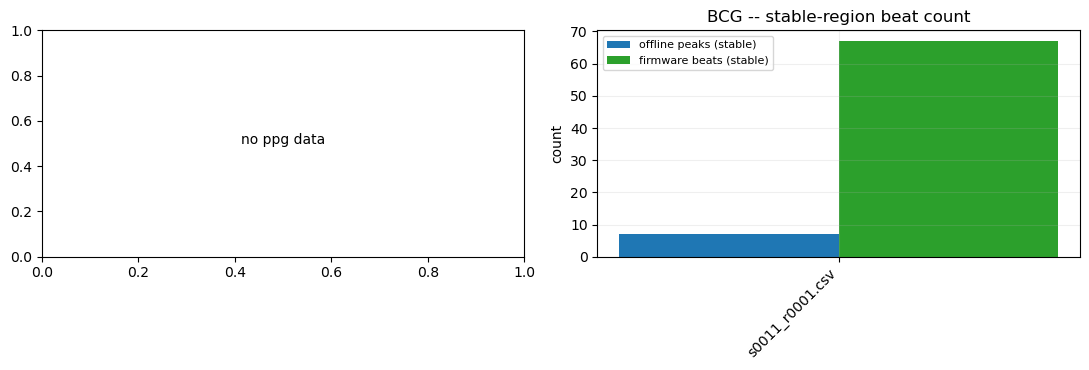

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)

for i, modality in enumerate(('ppg', 'bcg')):
    sub = df[df['modality'] == modality].dropna(subset=['bpm_median'])
    if len(sub) == 0:
        ax[i].text(0.5, 0.5, f'no {modality} data', ha='center',
                   transform=ax[i].transAxes)
        continue
    x = np.arange(len(sub))
    w = 0.4
    ax[i].bar(x - w/2, sub['n_peaks_stable'], w,
              color='#1F77B4', label='offline peaks (stable)')
    ax[i].bar(x + w/2, sub['n_fw_beats_stable'], w,
              color='#2CA02C', label='firmware beats (stable)')
    ax[i].set_xticks(x)
    ax[i].set_xticklabels(sub['file'], rotation=45, ha='right')
    ax[i].set_ylabel('count')
    ax[i].set_title(f'{modality.upper()} -- stable-region beat count')
    ax[i].legend(fontsize=8)
    ax[i].grid(alpha=0.2)

fig.tight_layout();

## 6. Noise floor + SNR comparison

Rest recordings should cluster with low `noise_rms` and high `snr_db`. Manhandled recordings show the reverse. Two subplots per modality make the comparison obvious across a session.

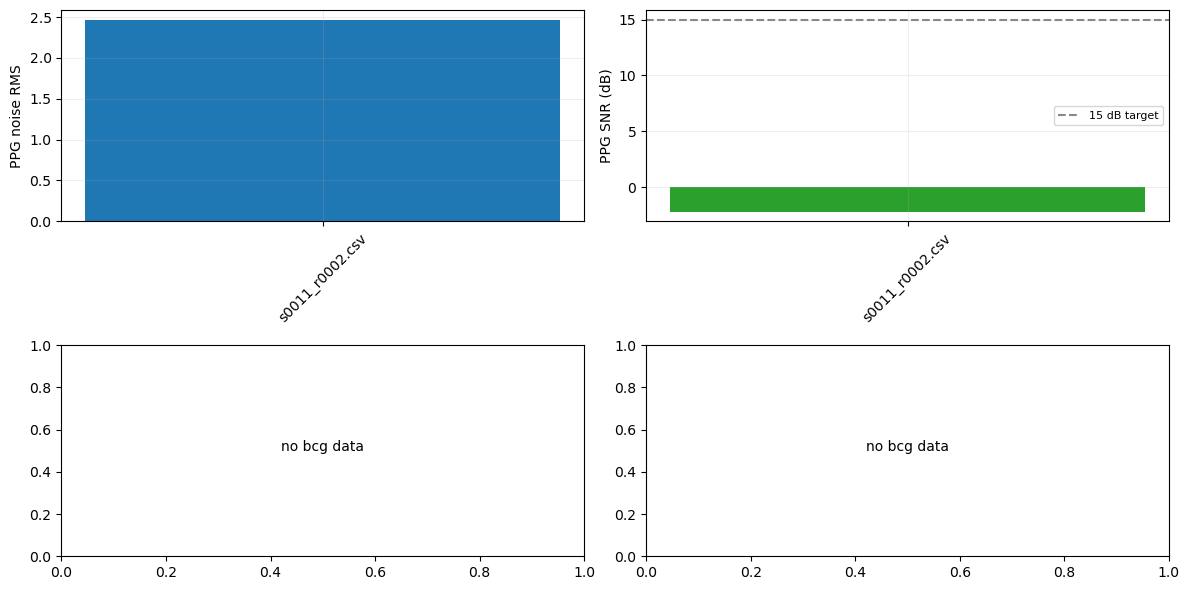

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for row, modality in enumerate(('ppg', 'bcg')):
    sub = df[df['modality'] == modality].dropna(subset=['snr_db'])
    if len(sub) == 0:
        for col in range(2):
            axs[row, col].text(0.5, 0.5, f'no {modality} data', ha='center',
                               transform=axs[row, col].transAxes)
        continue
    axs[row, 0].bar(sub['file'], sub['noise_rms'], color='#1F77B4')
    axs[row, 0].set_ylabel(f'{modality.upper()} noise RMS')
    axs[row, 0].tick_params(axis='x', rotation=45)
    axs[row, 0].grid(alpha=0.2)

    axs[row, 1].bar(sub['file'], sub['snr_db'], color='#2CA02C')
    axs[row, 1].set_ylabel(f'{modality.upper()} SNR (dB)')
    axs[row, 1].tick_params(axis='x', rotation=45)
    axs[row, 1].axhline(15, color='#888', ls='--', label='15 dB target')
    axs[row, 1].grid(alpha=0.2)
    axs[row, 1].legend(fontsize=8)

fig.tight_layout();

## 7. Save summary CSV

Write the long-format summary alongside the session folder so the next notebook run picks up the comparison across sessions.

In [9]:
from datetime import date
out = DATA_DIR.parent / f'kompic_analysis_summary_{date.today()}.csv'
df.to_csv(out, index=False)
print('wrote', out)

wrote /home/ivan/Projekti/Elektronika/Kompic-Wearable/kompic-wearable/docs/build_info/reference_files/kompic_data/kompic_analysis_summary_2026-08-27.csv
